In [1]:
import os
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score
from transformers import BertConfig, BertForSequenceClassification, AutoTokenizer, AutoModelForSequenceClassification, AdamW, get_linear_schedule_with_warmup
import torch
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
import torch.nn.functional as F
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
import sklearn.utils
import time
from torch.utils.data import TensorDataset

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def clean_text(text):
    if isinstance(text, (str, np.ndarray)): 
        if isinstance(text, str):
            text = text.lower()
            text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
            return text
        elif isinstance(text, np.ndarray):
            return np.array([clean_text(t) for t in text])
    elif pd.isnull(text): 
        return ""
    else:
        try:
            text = str(text)
            text = text.lower()
            text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
            return text
        except Exception as e:
            print(f"Error cleaning text: {e}, Text Type: {type(text)}, Text Value: {text}")
            return "" 

In [3]:
labeled_data = pd.read_csv("../data/eq-5d-200-records.tsv", sep="\t")

for col in ['Title', 'Abstract', 'Keywords']:
    labeled_data[col] = labeled_data[col].apply(clean_text)

labeled_data['combined_text'] =  labeled_data['Title'] + "[SEP]" +  labeled_data['Abstract'] + "[SEP]" + labeled_data['Keywords']

In [4]:
abstractslbl = labeled_data['Abstract']
keywordsslbl = labeled_data['Keywords']
titleslbl = labeled_data['Title']
lbls = labeled_data['Label']

In [5]:
print(np.shape(labeled_data))
print(labeled_data.columns)

(200, 6)
Index(['No', 'Label', 'Title', 'Abstract', 'Keywords', 'combined_text'], dtype='object')


In [6]:
labels = np.unique(lbls, return_counts=True)[0]
labelCounts=  np.unique(lbls, return_counts=True)[1]

print("Labels ", labels)
print("Label counts ", labelCounts)

Labels  [0 1]
Label counts  [ 79 121]


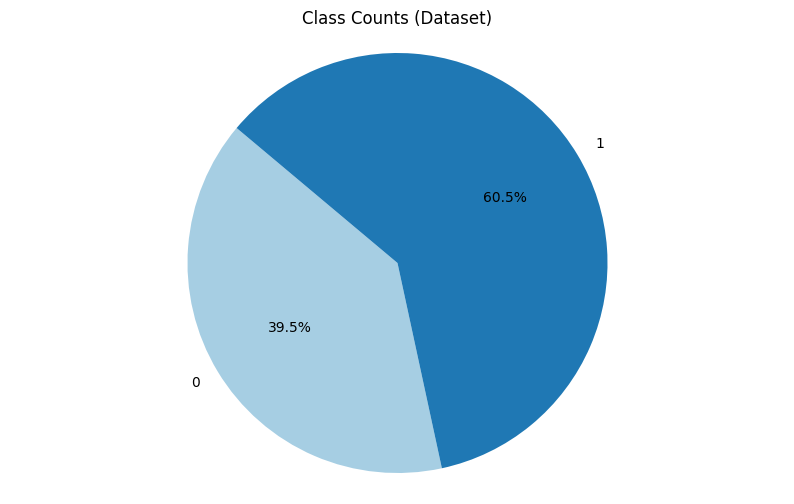

The label 0 has 79 records in the dataset.
The label 1 has 121 records in the dataset.


In [7]:
plt.figure(figsize=(10, 6))
plt.title("Class Counts (Dataset)")
plt.pie(labelCounts, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(labels))))
plt.axis('equal')
plt.show()

for i, label in enumerate(labels):
    print("The label", label, "has", labelCounts[i], "records in the dataset.")

In [8]:
labeled_data_shuffled = sklearn.utils.shuffle(labeled_data)

abstracts_shuffled = labeled_data_shuffled['Abstract'].values
keywords_shuffled = labeled_data_shuffled['Keywords'].values
titles_shuffled = labeled_data_shuffled['Title'].values
allLabels_shuffled = labeled_data_shuffled['Label'].values
allLabels_digit_shuffled = allLabels_shuffled.astype(int)

In [9]:
print(np.shape(labeled_data_shuffled))
print(np.shape(titles_shuffled))
print(np.shape(abstracts_shuffled))
print(np.shape(keywords_shuffled))

print(labeled_data_shuffled['combined_text'][0])

(200, 6)
(200,)
(200,)
(200,)
comparing measurement properties of eq5dy3l and eq5dy5l in paediatric patients[SEP]background the adult versions eq5d3l and eq5d5l have been extensive compared this is not the case for the eq5d youth versions the study aim was to compare the measurement properties and responsiveness of eq5dy3l and eq5dy5l in paediatric patients methods a sample of patients 816 years old with different diseases and a wide range of disease severity was asked to complete eq5dy3l eq5dy5l pedsql generic core scale and selected appropriate diseasespecific instruments three times eq5dy3l and eq5dy5l were compared in terms of feasibility redistribution properties discriminatory power convergent validity testretest reliability and responsiveness results 286 participating patients suffered from one of the following diseases major betathalassemia haemophilia acute lymphoblastic leukaemia acute illness missing responses were comparable between versions of the eq5dy suggesting comparab

In [10]:
train_data, test_data = train_test_split(labeled_data_shuffled, test_size=0.4, random_state=42)
print(np.shape(train_data))
print(np.shape(test_data))

_, val_data = train_test_split(test_data, test_size=0.3, random_state=42)
print(np.shape(train_data))
print(np.shape(test_data))
print(np.shape(val_data))



(120, 6)
(80, 6)
(120, 6)
(80, 6)
(24, 6)


In [11]:
tokenizer = AutoTokenizer.from_pretrained("allenai/scibert_scivocab_uncased")

/opt/conda/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [12]:
abstractslbltrain = train_data['Abstract']
keywordsslbltrain = train_data['Keywords']
titlelbltrain = train_data['Title']
lblstrain = train_data['Label']

In [13]:
print(np.shape(labeled_data))
print(labeled_data.columns)

(200, 6)
Index(['No', 'Label', 'Title', 'Abstract', 'Keywords', 'combined_text'], dtype='object')


In [14]:
labels = np.unique(lblstrain, return_counts=True)[0]
labelCounts=  np.unique(lblstrain, return_counts=True)[1]

print("Labels ", labels)
print("Label counts ", labelCounts)

Labels  [0 1]
Label counts  [46 74]


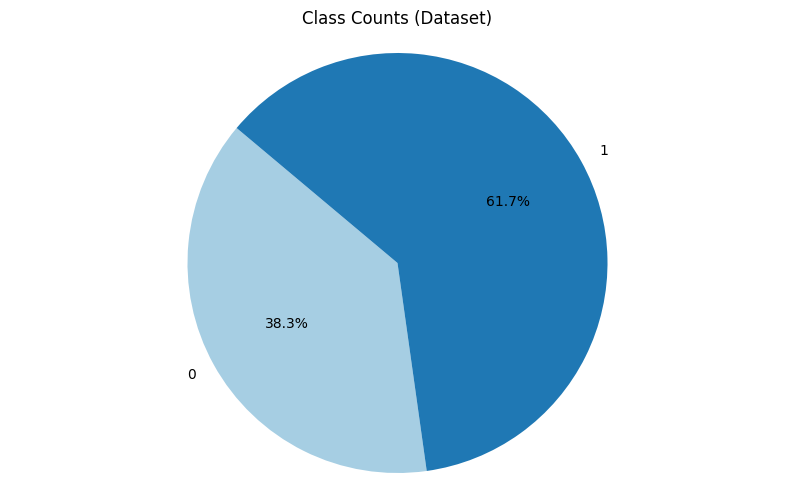

The label 0 has 46 records in the dataset.
The label 1 has 74 records in the dataset.


In [15]:
# Visualize domain counts in dataset
plt.figure(figsize=(10, 6))
plt.title("Class Counts (Dataset)")
plt.pie(labelCounts, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(labels))))
plt.axis('equal')
plt.show()

for i, label in enumerate(labels):
    print("The label", label, "has", labelCounts[i], "records in the dataset.")

In [16]:
abstractslbltest = test_data['Abstract']
keywordsslbltest = test_data['Keywords']
titlelbltest = test_data['Title']
lblstest = test_data['Label']

In [17]:
labels = np.unique(lblstest, return_counts=True)[0]
labelCounts=  np.unique(lblstest, return_counts=True)[1]

print("Labels ", labels)
print("Label counts ", labelCounts)

Labels  [0 1]
Label counts  [33 47]


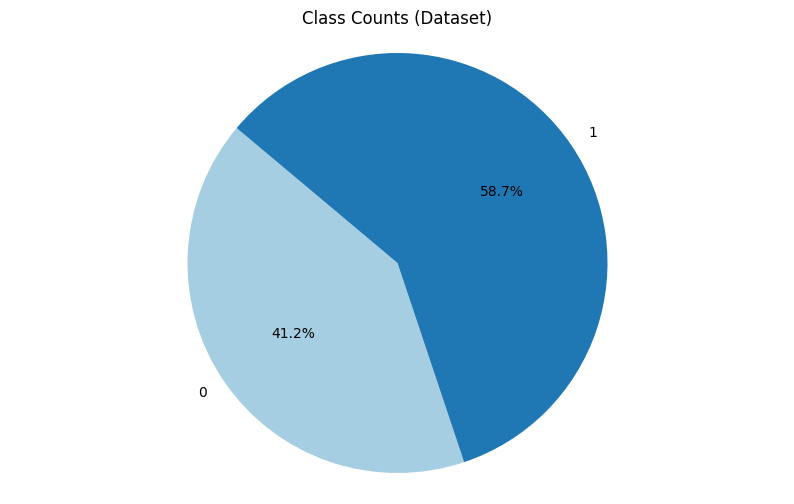

The label 0 has 33 records in the dataset.
The label 1 has 47 records in the dataset.


In [18]:
plt.figure(figsize=(10, 6))
plt.title("Class Counts (Dataset)")
plt.pie(labelCounts, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(labels))))
plt.axis('equal')
plt.show()

for i, label in enumerate(labels):
    print("The label", label, "has", labelCounts[i], "records in the dataset.")

In [19]:
abstractslblval = val_data['Abstract']
keywordsslblval = val_data['Keywords']
titlelblval = val_data['Title']
lblsval = val_data['Label']

In [20]:
labels = np.unique(lblsval, return_counts=True)[0]
labelCounts=  np.unique(lblsval, return_counts=True)[1]

print("Labels ", labels)
print("Label counts ", labelCounts)

Labels  [0 1]
Label counts  [ 9 15]


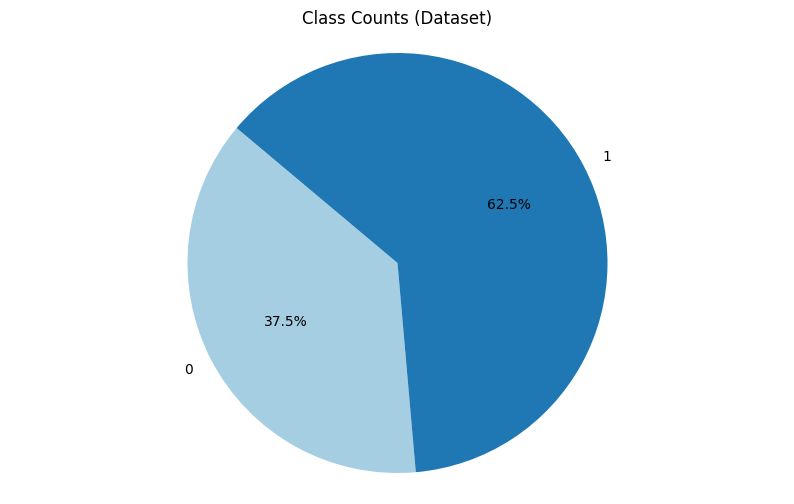

The label 0 has 9 records in the dataset.
The label 1 has 15 records in the dataset.


In [21]:
plt.figure(figsize=(10, 6))
plt.title("Class Counts (Dataset)")
plt.pie(labelCounts, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(labels))))
plt.axis('equal')
plt.show()

for i, label in enumerate(labels):
    print("The label", label, "has", labelCounts[i], "records in the dataset.")

In [22]:
def encode_data(data, tokenizer, max_length=128, labeled=True):
    inputs = tokenizer(
        data['combined_text'].tolist(),
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    if labeled and 'Label' in data.columns:
        labels = torch.tensor(data['Label'].values.astype(int))
        return TensorDataset(inputs['input_ids'], inputs['attention_mask'], labels)
    else:
        return TensorDataset(inputs['input_ids'], inputs['attention_mask'])


In [23]:
train_dataset = encode_data(train_data, tokenizer)
val_dataset = encode_data(val_data, tokenizer)
test_dataset = encode_data(test_data, tokenizer)

In [24]:
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=32)
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=32)
test_dataloader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=32)

In [25]:
print(len(np.unique(train_data['Label'])))
config = BertConfig.from_pretrained("allenai/scibert_scivocab_uncased")
config.num_labels = len(np.unique(train_data['Label']))  # Set the number of labels
model = BertForSequenceClassification(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

2


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31090, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [26]:
def calculate_metrics_f(valType, predictions, true_labels):
    if valType == 'test':
        cm = confusion_matrix(true_labels, predictions)
        report = classification_report(true_labels, predictions)
        f1_micro = f1_score(true_labels, predictions, average='micro')
        print("\nClassification Report:\n", report)
        return f1_micro
    elif valType == 'val':
        f1_micro = f1_score(true_labels, predictions, average='micro')
        return f1_micro

In [27]:
def calculate_metrics(valType, predictions, true_labels):
    # Confusion matrix
    if(valType == 'test'):
        cm = confusion_matrix(true_labels, predictions)
        print("Confusion Matrix:\n", cm)

        report = classification_report(true_labels, predictions, target_names=[str(i) for i in range(len(np.unique(true_labels)))])
        print("\nClassification Report:\n", report)

        f1_macro = f1_score(true_labels, predictions, average='macro')
        f1_micro = f1_score(true_labels, predictions, average='micro')
        f1_weighted = f1_score(true_labels, predictions, average='weighted')

        precision_macro = precision_score(true_labels, predictions, average='macro')
        precision_micro = precision_score(true_labels, predictions, average='micro')
        precision_weighted = precision_score(true_labels, predictions, average='weighted')

        recall_macro = recall_score(true_labels, predictions, average='macro')
        recall_micro = recall_score(true_labels, predictions, average='micro')
        recall_weighted = recall_score(true_labels, predictions, average='weighted')

        print(f"Macro F1 Score: {f1_macro}")
        print(f"Micro F1 Score: {f1_micro}")
        print(f"Weighted F1 Score: {f1_weighted}")

        print(f"Macro Precision: {precision_macro}")
        print(f"Micro Precision: {precision_micro}")
        print(f"Weighted Precision: {precision_weighted}")

        print(f"Macro Recall: {recall_macro}")
        print(f"Micro Recall: {recall_micro}")
        print(f"Weighted Recall: {recall_weighted}")

    elif(valType == 'val'):
        cm = confusion_matrix(true_labels, predictions)
        f1_macro = f1_score(true_labels, predictions, average='macro')
        f1_micro = f1_score(true_labels, predictions, average='micro')
        f1_weighted = f1_score(true_labels, predictions, average='weighted')

        precision_macro = precision_score(true_labels, predictions, average='macro')
        precision_micro = precision_score(true_labels, predictions, average='micro')
        precision_weighted = precision_score(true_labels, predictions, average='weighted')

        recall_macro = recall_score(true_labels, predictions, average='macro')
        recall_micro = recall_score(true_labels, predictions, average='micro')
        recall_weighted = recall_score(true_labels, predictions, average='weighted')
        # print('Val Micro F1:', f1_micro)
        return f1_micro

In [28]:

epochs = 100
learning_rates = [1e-4, 2e-4, 5e-4, 1e-5, 2e-5, 5e-5, 1e-6, 2e-6, 5e-6]
early_stopping_patience = 10
best_val_f1 = 0
early_stopping_counter = 0

for lr in learning_rates:
    early_stopping_counter = 0
    print(f"\nTraining with learning rate: {lr}")
    optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
    total_steps = len(train_dataloader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0.1 * total_steps, num_training_steps=total_steps)

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs}", unit="batch"):
            batch = tuple(t.to(device) for t in batch)
            input_ids, input_mask, labels = batch
            model.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=input_mask, labels=labels)
            loss = outputs.loss
            total_train_loss += loss.item()
            loss.backward()
            optimizer.step()
            scheduler.step()
        avg_train_loss = total_train_loss / len(train_dataloader)
        print(f"Train Loss: {avg_train_loss}")

        # Validation
        model.eval()
        predictions, true_labels = [], []
        for batch in val_dataloader:
            batch = tuple(t.to(device) for t in batch)
            input_ids, input_mask, labels = batch
            with torch.no_grad():
                outputs = model(input_ids=input_ids, attention_mask=input_mask)
            logits = outputs.logits.detach().cpu().numpy()
            batch_predictions = np.argmax(logits, axis=1)
            predictions.extend(batch_predictions)
            true_labels.extend(labels.to('cpu').numpy())
        val_f1 = f1_score(true_labels, predictions, average='micro')
        print(f"Validation Micro F1: {val_f1}")
        val_micro_f1 = calculate_metrics_f('val', predictions, true_labels)
        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss}, Val Micro F1: {val_micro_f1}")

        # Early stopping check
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            early_stopping_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print("Best model saved.")
        else:
            early_stopping_counter += 1
            if early_stopping_counter >= early_stopping_patience:
                print("Early stopping applied.")
                break

# Load the best model for testing
model.load_state_dict(torch.load('best_model.pth'))
print("Best model loaded.")


Training with learning rate: 0.0001


/opt/conda/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/100: 100%|██████████| 4/4 [00:09<00:00,  2.26s/batch]


Train Loss: 0.7009724527597427
Validation Micro F1: 0.625
Epoch 1/100, Train Loss: 0.7009724527597427, Val Micro F1: 0.625
Best model saved.


Epoch 2/100: 100%|██████████| 4/4 [00:08<00:00,  2.11s/batch]


Train Loss: 0.7021608948707581
Validation Micro F1: 0.625
Epoch 2/100, Train Loss: 0.7021608948707581, Val Micro F1: 0.625


...

Train Loss: 0.6745321154594421
Validation Micro F1: 0.625
Epoch 9/100, Train Loss: 0.6745321154594421, Val Micro F1: 0.625


Epoch 10/100: 100%|██████████| 4/4 [00:08<00:00,  2.18s/batch]


Train Loss: 0.6783097237348557
Validation Micro F1: 0.625
Epoch 10/100, Train Loss: 0.6783097237348557, Val Micro F1: 0.625
Early stopping applied.


/tmp/ipykernel_1661108/3459882632.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


Best model loaded.


In [29]:
# Evaluation
model.eval()
predictions = []
true_labels = []

for batch in test_dataloader:
    batch = tuple(t.to(device) for t in batch)
    input_ids, input_mask, labels = batch

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=input_mask)
        logits = outputs.logits

    logits = logits.detach().cpu().numpy()
    label_ids = labels.to('cpu').numpy()

    batch_predictions = np.argmax(logits, axis=1)
    predictions.extend(batch_predictions)
    true_labels.extend(label_ids)

# Calculate and print metrics
calculate_metrics('test', predictions, true_labels)

Confusion Matrix:
 [[ 0 33]
 [ 0 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.59      1.00      0.74        47

    accuracy                           0.59        80
   macro avg       0.29      0.50      0.37        80
weighted avg       0.35      0.59      0.43        80

Macro F1 Score: 0.3700787401574803
Micro F1 Score: 0.5875
Weighted F1 Score: 0.43484251968503934
Macro Precision: 0.29375
Micro Precision: 0.5875
Weighted Precision: 0.34515625
Macro Recall: 0.5
Micro Recall: 0.5875
Weighted Recall: 0.5875


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/m

In [30]:
# Calculate and display test metrics
print("\nTest Metrics:")
print("Confusion Matrix:\n", confusion_matrix(true_labels, predictions))
print("Classification Report:\n", classification_report(true_labels, predictions))
print("Macro F1:", f1_score(true_labels, predictions, average='macro'))
print("Micro F1:", f1_score(true_labels, predictions, average='micro'))
print("Weighted F1:", f1_score(true_labels, predictions, average='weighted'))


Test Metrics:
Confusion Matrix:
 [[ 0 33]
 [ 0 47]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.59      1.00      0.74        47

    accuracy                           0.59        80
   macro avg       0.29      0.50      0.37        80
weighted avg       0.35      0.59      0.43        80

Macro F1: 0.3700787401574803
Micro F1: 0.5875
Weighted F1: 0.43484251968503934


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
for name, param in model.named_parameters():
    if not param.is_contiguous():
        param.data = param.data.contiguous()
model.save_pretrained('scibert_200_labeled_data_training_all')